|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 7:</h2>|<h1>Modern vLLM<h1>|
|<h2>Section:</h2>|<h1>Tensor parallelism<h1>|
|<h2>Lecture:</h2>|<h1><b>Where to cut, and how few times the ranks have to talk<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Cut the model in half, two times

A model that does not fit on one card must go across several cards. The
question is where to cut. The amount of communication that each cut needs
gives the whole answer.

All of the code below runs on the CPU. The lesson is where the communication
lands. It is not the speed.

In [2]:
import torch
torch.manual_seed(0)
HIDDEN, MLP_HIDDEN = 256, 1024
inputs = torch.randn(4, HIDDEN)
up_weight = torch.randn(HIDDEN, MLP_HIDDEN) / HIDDEN**0.5
down_weight = torch.randn(MLP_HIDDEN, HIDDEN) / MLP_HIDDEN**0.5
reference = torch.relu(inputs @ up_weight) @ down_weight
print('one device:', tuple(reference.shape))

one device: (4, 256)


### Column parallel, then row parallel

Split the first matrix by **columns**: each [rank](../../GLOSSARY.md#rank) owns some of the hidden
units and computes them independently. No communication, because `relu` is
elementwise and each hidden unit depends only on its own column.

Split the second by **rows**, matching. Each rank now holds a partial sum of
the full output, and adding them up is one [all-reduce](../../GLOSSARY.md#all-reduce).

Column then row, and exactly one [collective](../../GLOSSARY.md#collective) between them. Any other pairing
needs two.

In [3]:
RANKS = 2
up_shards = list(up_weight.chunk(RANKS, dim=1))      # columns
down_shards = list(down_weight.chunk(RANKS, dim=0))  # rows, to match
partials = []
for rank in range(RANKS):
  hidden_units = torch.relu(inputs @ up_shards[rank])   # the hidden units of this rank
  partials.append(hidden_units @ down_shards[rank])     # a PARTIAL output
output = sum(partials)                                  # <- the one all-reduce
print('max difference from one device:', (output - reference).abs().max().item())
print(f'\nfor each rank: up {tuple(up_shards[0].shape)}, down {tuple(down_shards[0].shape)}')
print(f'each rank holds {100/RANKS:.0f}% of the weights')

max difference from one device: 0.0

for each rank: up (256, 512), down (512, 256)
each rank holds 50% of the weights


### What it costs to talk

In [4]:
# Do not put milliseconds in this. Each side of the comparison is bytes
# divided by a bandwidth. So the clock cancels, and a ratio stays.
#
#   collectives for each step: 4 B d (R-1)/R L C bytes, across link I.
#   compute for each step:     weights W = 24 d^2 L bytes, R ranks, HBM.
#
# All the terms on the left of the x are your model and your batch. The
# term on the right is one number about your machine: how many times
# faster its memory is than its interconnect.
def comm_over_compute(batch, hidden, ranks, bandwidth_ratio, collectives=1):
  """Collective time divided by compute time. It has no unit and no clock.

       comm      B C (R-1)     HBM
       ----  =  -----------  x -----
       step        6 d           I
  """
  return batch * collectives * (ranks-1) / (6*hidden) * bandwidth_ratio

def break_even_batch(hidden, ranks, bandwidth_ratio, collectives=1):
  """The batch at which the ratio is 1: the ranks talk as long as they compute."""
  return 6*hidden / ((ranks-1) * bandwidth_ratio * collectives)

LINKS = {'NVLink (same node)': 1.0,     # interconnect ~ HBM
         'PCIe 4.0 x16':       25.0,    # HBM approximately 25x faster
         'Ethernet 100GbE':    200.0}
MODEL_HIDDEN, MODEL_RANKS = 4096, 8
print(f"{'interconnect':>20} " + ' '.join(f'B={batch:<6}' for batch in (1, 32, 256)))
for name, bandwidth_ratio in LINKS.items():
  ratios = [comm_over_compute(batch, MODEL_HIDDEN, MODEL_RANKS, bandwidth_ratio)
            for batch in (1, 32, 256)]
  print(f'{name:>20} ' + ' '.join(f'{ratio:<8.3f}' for ratio in ratios))
print('\n(8 ranks, hidden 4096, one collective for each block.)')
print('A value of 1.0 means that the ranks talk as long as they compute.')

        interconnect B=1      B=32     B=256   
  NVLink (same node) 0.000    0.009    0.073   
        PCIe 4.0 x16 0.007    0.228    1.823   
     Ethernet 100GbE 0.057    1.823    14.583  

(8 ranks, hidden 4096, one collective for each block.)
A value of 1.0 means that the ranks talk as long as they compute.


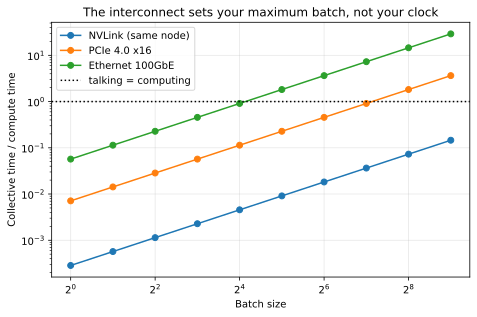

  NVLink (same node): talking becomes longer than computing at batch 3,511
        PCIe 4.0 x16: talking becomes longer than computing at batch 140
     Ethernet 100GbE: talking becomes longer than computing at batch 18


In [5]:
batches = np.array([1,2,4,8,16,32,64,128,256,512])
plt.figure(figsize=(7.5,4.6))
for name, bandwidth_ratio in LINKS.items():
  plt.plot(batches, [comm_over_compute(batch, MODEL_HIDDEN, MODEL_RANKS, bandwidth_ratio)
                     for batch in batches], 'o-', label=name)
plt.axhline(1.0, color='k', ls=':', label='talking = computing')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Batch size')
plt.ylabel('Collective time / compute time')
plt.title('The interconnect sets your maximum batch, not your clock')
plt.legend()
plt.grid(alpha=.3)
plt.show()
for name, bandwidth_ratio in LINKS.items():
  batch = break_even_batch(MODEL_HIDDEN, MODEL_RANKS, bandwidth_ratio)
  print(f'{name:>20}: talking becomes longer than computing at batch {batch:,.0f}')

### One number about your machine, and it is not a speed

`HBM / interconnect` is the whole hardware input. Not gigabytes per second:
the *ratio* of the two bandwidths, which is dimensionless and which you can
look up for any node without measuring anything.

On NVLink it is about 1 and the collectives never matter. Over PCIe it is
around 25 and they overtake the compute somewhere in the low hundreds of
sequences. Over a network it is in the hundreds and [tensor parallelism](../../GLOSSARY.md#tensor-parallelism) is
essentially a way to make one large model run slowly.

Everything else in the formula is yours to choose:

- **batch** appears linearly, and every plot in Part 2 said to raise it
- **collectives per block** is 1 if you [sharded](../../GLOSSARY.md#shard) correctly and 2 if you did not
- **hidden size** is in the denominator, so bigger models tolerate more
  splitting, which is convenient because they are the ones that need it

So tensor parallelism and continuous batching pull against each other, and the
bandwidth ratio sets where they balance. That is why serving nodes are sold
with NVLink, and why the same eight cards on PCIe are a different machine.

### Attention splits the same way, for a different reason

Heads are independent until the output projection. So give each rank whole
heads. Use column-parallel on QKV and row-parallel on the output projection.
That gives one all-reduce for each block. The same shape gives the same single
collective.

You cannot split one head across ranks, because softmax reduces over the whole
row. That is the same constraint that made split-K in stage 08c need a merge
pass. Here it applies one level up.

### And the thing to remember

Tensor parallelism is not a way to go faster. On the work of one card it is
always slower, because you added collectives to arithmetic that was already
correct.

It is a way to run a model that does not fit. The design question is always
the same: **how few times in each layer must the ranks talk?**

The answer is one time. Column then row gives you that.

Stage 20 makes you build it with real collectives, on two ranks on one
machine. It checks that the 2-rank output matches the 1-rank output exactly.

    ./vc guide 20